In [82]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from apyori import apriori

## Подготовка данных

In [83]:
# Функция загрузки и подготовки данных
def load_data(filename):
    """
    Загружает данные из .CSV файла и преобразует их в список транзакций.
    
    :params:
    filename -- имя CSV-файла с покупками (товары в строке через запятую)
    
    :returns:
    transactions -- список списков (каждый внутренний список - это покупка)
    """
    # Читаем CSV, разделитель — запятая, без заголовков
    data = pd.read_csv(filename, header=None, encoding='cp1251')
    
    # Преобразуем строки в списки товаров
    transactions = data.apply(lambda row: [item.strip() for item in row.dropna()], axis=1).tolist()
    
    return transactions


In [84]:
# Загружаем данные
data_path = "baskets.csv"
transactions = load_data(data_path)
print(f"Загружено {len(transactions)} транзакций. Пример данных:")
for transaction in transactions[:5]:
    print(transaction)

Загружено 7501 транзакций. Пример данных:
['креветки', 'миндаль', 'авокадо', 'овощная смесь', 'зеленый виноград', 'цельнозерновая мука', 'батат', 'творог', 'энергетический напиток', 'томатный сок', 'низкокалорийный йогурт', 'зеленый чай', 'мед', 'салат', 'минеральная вода', 'лосось', 'ягодный сок', 'замороженный смузи', 'шпинат', 'оливковое масло']
['гамбургер', 'фрикадельки', 'яйца']
['чатни']
['индейка', 'авокадо']
['минеральная вода', 'молоко', 'энергетический батончик', 'рис', 'зеленый чай']


## Поиск ассоциативных правил

In [109]:
def run_apriori(transactions, min_support, min_confidence, sort_method = "support"):
    """
    Выполняет алгоритм Apriori с библиотекой apyori.
    
    :param:
    transactions -- список транзакций (списков товаров)
    min_support -- минимальный порог поддержки (в долях, например 0.05)
    min_confidence -- минимальный порог достоверности (в долях, например 0.7)
    
    :returns:
    DataFrame с найденными частыми наборами и их поддержкой
    """
    start_time = time.time()
    results = list(apriori(transactions, min_support=min_support, min_confidence=min_confidence))
    execution_time = time.time() - start_time

    association_rules = []
    for result in results:
        for rule in result.ordered_statistics:
            antecedent = tuple(rule.items_base)
            consequent = tuple(rule.items_add)
            support = result.support
            confidence = rule.confidence
            lift = confidence / support
            association_rules.append((antecedent, consequent, support, confidence, lift))
    
    df = pd.DataFrame(association_rules, columns=["antecedent", "consequent", "support", "confidence", "lift"])
    
    # Сортируем по заданному критерию
    if sort_method == "support":
        df = df.sort_values(by="support", ascending=False)
    elif sort_method == "lexicographic":
        df = df.sort_values(by="itemsets", ascending=True)
    elif sort_method == "confidence":
        df = df.sort_values(by="confidence", ascending=False)
    elif sort_method == "lift":
        df = df.sort_values(by="lift", ascending=False)
        
    return df, execution_time

def filter_rules_by_length(association_rules, max_length=7):
    """
    Фильтрует ассоциативные правила по условию, что антецедент и консеквент суммарно не более max_length объектов.
    
    Аргументы:
    association_rules -- DataFrame с ассоциативными правилами
    max_length -- максимальное количество объектов в антецеденте и консеквенте
    
    Возвращает:
    DataFrame с отфильтрованными ассоциативными правилами
    """
    # Фильтруем правила по длине
    filtered_rules = association_rules[association_rules['antecedent'].apply(lambda x: len(x)) + association_rules['consequent'].apply(lambda x: len(x)) <= max_length]
    
    return filtered_rules


In [86]:
rule_count = list()
association_rules = list()
confidence_values = range(20, 70, 5)
for min_confidence_value in confidence_values:
    received_association_rules, _ = run_apriori(transactions, min_support=1/100, min_confidence=min_confidence_value/100, sort_method = "support")
    
    rule_count.append(len(received_association_rules))
    association_rules.append(received_association_rules)

In [96]:
raw_execution_time = list([list() for _ in range(len(confidence_values))])

for _ in range(100):
    for j in range(len(confidence_values)):
        _, exec_time = run_apriori(transactions, min_support=1/100, min_confidence=confidence_values[j]/100, sort_method = "support")
        raw_execution_time[j].append(exec_time)

execution_time = [sum(x) / len(x) for x in raw_execution_time]

In [88]:
for i in range(len(association_rules)):
    print(f"Минимальное значение достоверности {confidence_values[i]:.0f}%: {association_rules[i].shape[0]} ассоциативных правил")
    print(association_rules[i])
    print("-"*40)
    

Минимальное значение достоверности 20%: 164 ассоциативных правил
                            antecedent           consequent   support  \
0                                   ()  (минеральная вода,)  0.238368   
61                         (макароны,)  (минеральная вода,)  0.061192   
62                 (минеральная вода,)          (макароны,)  0.061192   
94                          (шоколад,)  (минеральная вода,)  0.052660   
93                 (минеральная вода,)           (шоколад,)  0.052660   
..                                 ...                  ...       ...   
137  (минеральная вода, картофель-фри)          (макароны,)  0.010399   
92                           (хлопья,)  (минеральная вода,)  0.010265   
128   (говяжий фарш, минеральная вода)              (яйца,)  0.010132   
110                             (суп,)           (шоколад,)  0.010132   
129               (говяжий фарш, яйца)  (минеральная вода,)  0.010132   

     confidence  
0      0.238368  
61     0.325532  
62  

In [89]:
# Максимальное количество объектов в правиле
max_objects_count = []

for association_rules_df in association_rules:
    if len(association_rules_df) > 0:
        max_objects = association_rules_df.apply(lambda row: len(row['antecedent']) + len(row['consequent']), axis=1).max()
        filtered_count = len(filter_rules_by_length(association_rules_df, max_length=7))
    else:
        max_objects = 0
        filtered_count = 0
    max_objects_count.append(max_objects)

## Вывод графиков

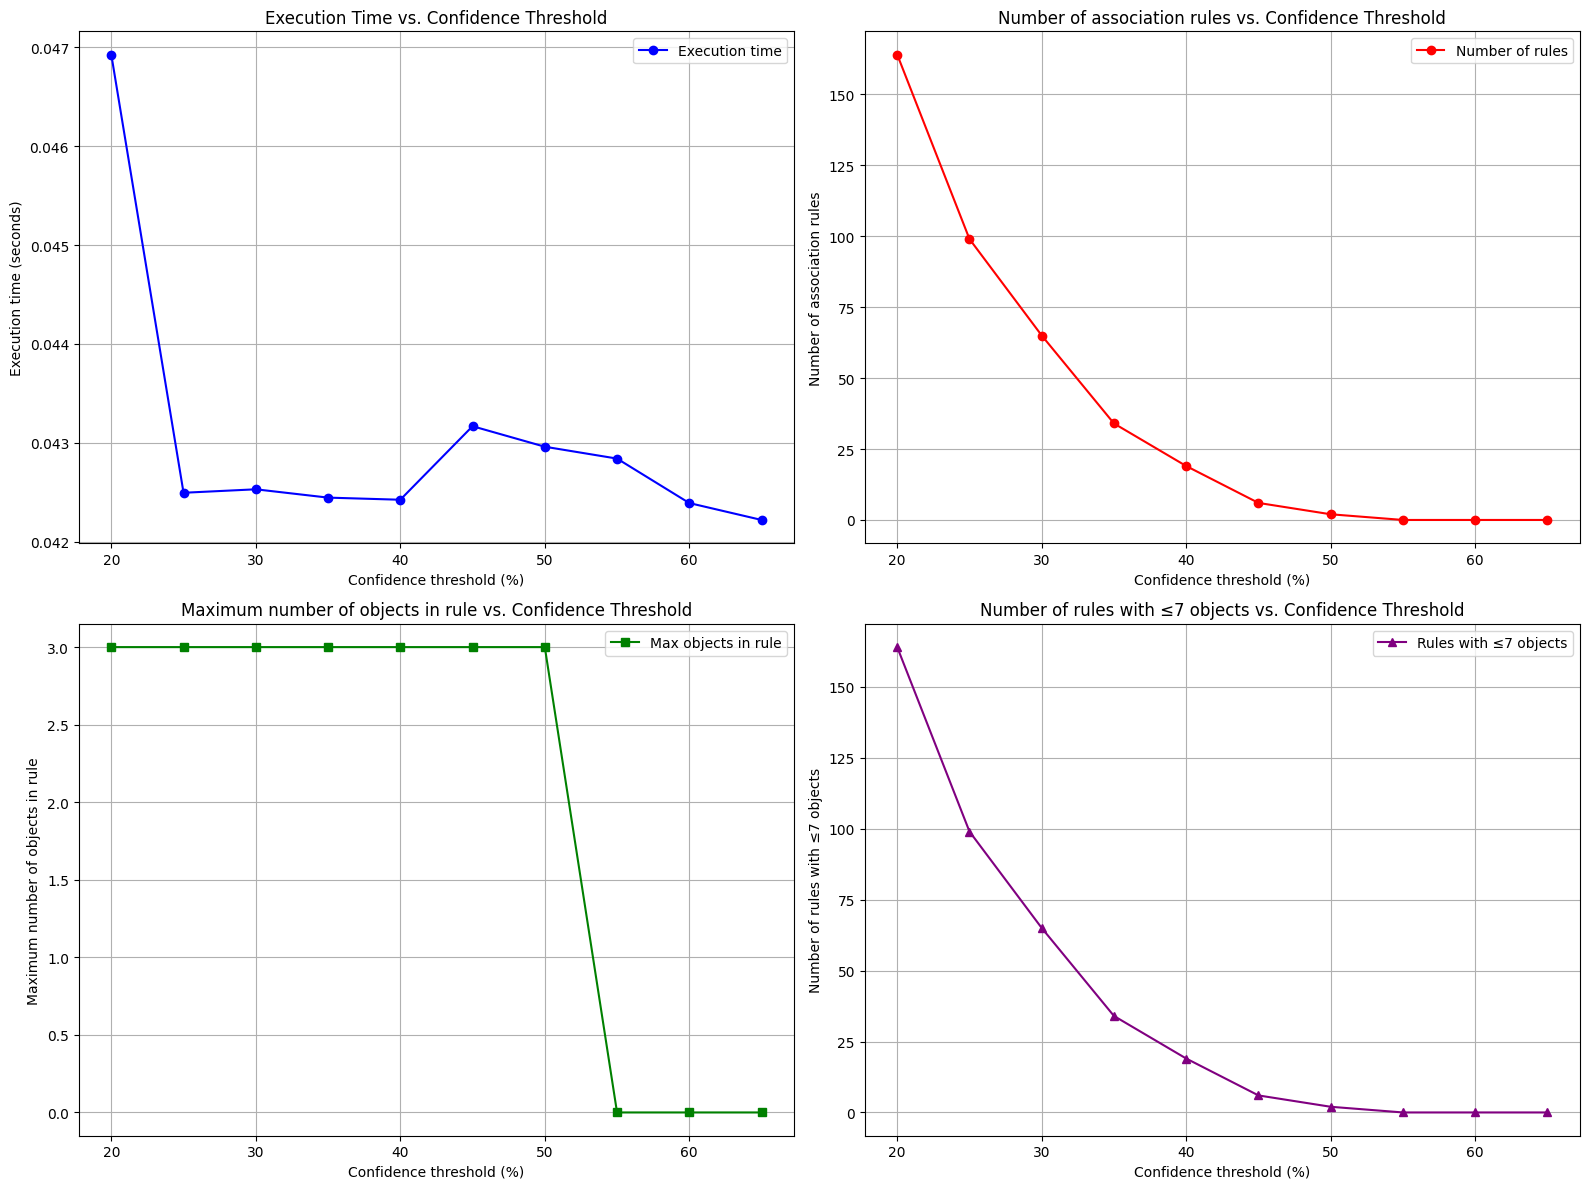

In [97]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.plot(confidence_values, execution_time, marker="o", color="b", label="Execution time")
plt.xlabel("Confidence threshold (%)")
plt.ylabel("Execution time (seconds)")
plt.title("Execution Time vs. Confidence Threshold")
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(confidence_values, rule_count, marker="o", color="red", label="Number of rules")
plt.xlabel("Confidence threshold (%)")
plt.ylabel("Number of association rules")
plt.title("Number of association rules vs. Confidence Threshold")
plt.legend()
plt.grid()

# График максимального количества объектов в правиле
plt.subplot(2, 2, 3)
plt.plot(confidence_values, max_objects_count, marker="s", color="green", label="Max objects in rule")
plt.xlabel("Confidence threshold (%)")
plt.ylabel("Maximum number of objects in rule")
plt.title("Maximum number of objects in rule vs. Confidence Threshold")
plt.legend()
plt.grid()

# График количества правил с ≤7 объектами
plt.subplot(2, 2, 4)
plt.plot(confidence_values, [len(filter_rules_by_length(rule)) for rule in association_rules], marker="^", color="purple", label="Rules with ≤7 objects")
plt.xlabel("Confidence threshold (%)")
plt.ylabel("Number of rules with ≤7 objects")
plt.title("Number of rules with ≤7 objects vs. Confidence Threshold")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Вывод списка правил, где антецедент и консеквент суммарно включают в себя не более семи объектов

In [108]:
# Сортировка по значению confidence
rules, _ = run_apriori(transactions, min_support=1/100, min_confidence=20/100, sort_method="confidence")
filtered_rules = filter_rules_by_length(rules, max_length=7)
filtered_rules

,antecedent,consequent,support,confidence,lift
129,"(говяжий фарш, яйца)","(минеральная вода,)",0.010132,0.506667,50.006667
123,"(говяжий фарш, молоко)","(минеральная вода,)",0.011065,0.503030,45.460606
126,"(шоколад, говяжий фарш)","(минеральная вода,)",0.010932,0.473988,43.358382
134,"(замороженные овощи, молоко)","(минеральная вода,)",0.011065,0.468927,42.378531
117,"(макароны, блинчики)","(минеральная вода,)",0.011732,0.458333,39.067708
...,...,...,...,...,...
80,"(минеральная вода,)","(молоко,)",0.047994,0.201342,4.195190
41,"(картофель-фри,)","(шоколад,)",0.034395,0.201248,5.851014
110,"(суп,)","(шоколад,)",0.010132,0.200528,19.791557
132,"(минеральная вода, макароны)","(замороженные овощи,)",0.012265,0.200436,16.342048


In [ ]:
# Сортировка по значению support
rules, _ = run_apriori(transactions, min_support=1/100, min_confidence=20/100, sort_method="support")
filtered_rules = filter_rules_by_length(rules, max_length=7)
filtered_rules

,antecedent,consequent,support,confidence
0,(),"(минеральная вода,)",0.238368,0.238368
61,"(макароны,)","(минеральная вода,)",0.061192,0.325532
62,"(минеральная вода,)","(макароны,)",0.061192,0.256711
94,"(шоколад,)","(минеральная вода,)",0.052660,0.321400
93,"(минеральная вода,)","(шоколад,)",0.052660,0.220917
...,...,...,...,...
137,"(минеральная вода, картофель-фри)","(макароны,)",0.010399,0.308300
92,"(хлопья,)","(минеральная вода,)",0.010265,0.398964
128,"(говяжий фарш, минеральная вода)","(яйца,)",0.010132,0.247557
110,"(суп,)","(шоколад,)",0.010132,0.200528


In [112]:
# Сортировка по значению support
rules, _ = run_apriori(transactions, min_support=1/100, min_confidence=20/100, sort_method="lift")
filtered_rules = filter_rules_by_length(rules, max_length=7)
filtered_rules

,antecedent,consequent,support,confidence,lift
129,"(говяжий фарш, яйца)","(минеральная вода,)",0.010132,0.506667,50.006667
123,"(говяжий фарш, молоко)","(минеральная вода,)",0.011065,0.503030,45.460606
126,"(шоколад, говяжий фарш)","(минеральная вода,)",0.010932,0.473988,43.358382
134,"(замороженные овощи, молоко)","(минеральная вода,)",0.011065,0.468927,42.378531
141,"(макароны, оливковое масло)","(минеральная вода,)",0.010665,0.449438,42.140449
...,...,...,...,...,...
62,"(минеральная вода,)","(макароны,)",0.061192,0.256711,4.195190
80,"(минеральная вода,)","(молоко,)",0.047994,0.201342,4.195190
96,"(минеральная вода,)","(яйца,)",0.050927,0.213647,4.195190
93,"(минеральная вода,)","(шоколад,)",0.052660,0.220917,4.195190
